# CMU-MOSEI — RAW DATASET → EDA → 3-MODALITY FEATURES → FINAL PICKLE

Text = BERT (`bert-base-uncased` (English)), Audio = openSMILE eGeMAPSv02 (88-d), Visual = ResNet18 (512-d).

**Design rules of this notebook**
* Raw files are never modified. Everything generated goes to `MyDrive/mplmm_final_deliverables/outputs/CMU-MOSEI/`.
* Text is read from the label file (`text` column). Audio is extracted from the video files with ffmpeg (16 kHz mono) unless real audio files exist.
* Unique sample key = `<video id>_<clip number>` (e.g. -3g5yACwYnA + 0 -> -3g5yacwyna_0), built identically from the label file and from file paths.
* No silent failures: errors are counted and printed; a missing modality is stored as `None`, never as fake zeros.
* Everything expensive is **cached on Drive** (wavs, text / audio / visual features), so a Colab disconnect never costs finished work. Re-running skips finished steps.

Flow: `setup → discover raw files → columns/shapes/types/stats → ID matching → EDA → audio extraction → BERT / openSMILE / ResNet18 → final pickle → sanity check`

## 0. Install packages and mount Drive

In [2]:
# Run once per Colab session (~1 min). ffmpeg is already present on Colab.
!pip -q install opensmile transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 7.7 MB/s eta 0:00:00


In [1]:
from pathlib import Path
import os, sys, json, pickle, warnings, re, glob, subprocess, shutil
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
except ImportError:
    drive = None
    print("google.colab cannot be imported -> this kernel is NOT Google Colab.")

if drive is not None:
    try:
        drive.mount("/content/drive")      # approve the pop-up
    except Exception as e:
        print("Drive mount FAILED with:", repr(e))   # the real reason
        raise

DRIVE_ROOT = Path(os.environ.get("MPLMM_DRIVE_ROOT", "/content/drive/MyDrive"))
# Not on Colab? Uncomment and edit this line to the folder that CONTAINS CMU-MOSEI/ :
# DRIVE_ROOT = Path("/path/to/folder/containing/CMU-MOSEI")

# Stop before creating folders. mkdir on an unmounted Colab creates a fake local MyDrive.
IN_COLAB = "google.colab" in sys.modules
if not DRIVE_ROOT.exists() or (IN_COLAB and not os.path.ismount("/content/drive")):
    raise RuntimeError("Google Drive is NOT mounted. Run this cell again, approve the pop-up, "
                       "wait for 'Mounted at /content/drive'. If it keeps failing: "
                       "Runtime > Restart session, then re-run.")

DELIV_ROOT = DRIVE_ROOT / "mplmm_final_deliverables"
DELIV_ROOT.mkdir(parents=True, exist_ok=True)
print("Deliverables root:", DELIV_ROOT)

Mounted at /content/drive
Deliverables root: /content/drive/MyDrive/mplmm_final_deliverables


## 1. Configuration (paths as before; raw files are never modified)

In [3]:
DATASET_NAME = "CMU-MOSEI"
DATASET_ROOT = DRIVE_ROOT / "CMU-MOSEI"
RAW_ROOT     = DATASET_ROOT / "Raw"

OUT_ROOT      = DELIV_ROOT / "outputs" / "CMU-MOSEI"
FIG_ROOT      = OUT_ROOT / "figures"
TABLE_ROOT    = OUT_ROOT / "tables"
ARTIFACT_ROOT = OUT_ROOT / "artifacts"
CACHE_ROOT    = ARTIFACT_ROOT / "cache"          # resumable feature cache (survives Colab disconnects)
WAV_DIR       = ARTIFACT_ROOT / "wav"            # on Drive: survives disconnects
for p in [OUT_ROOT, FIG_ROOT, TABLE_ROOT, ARTIFACT_ROOT, CACHE_ROOT, WAV_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ---- feature settings ----
TEXT_MODEL      = "bert-base-uncased"
MAX_TEXT_LEN    = 64
N_FRAMES        = 5                     # frames sampled per clip for ResNet18
FORCE_RECOMPUTE = False                 # True = ignore cached features and recompute everything
RUN_FEATURES    = True                  # False = only inspect + EDA
MAIN_LABEL_OVERRIDE = None              # e.g. "label_M"; only needed if the automatic choice below is wrong

def _ls(p, n=40):
    try:    return sorted(x.name for x in p.iterdir())[:n]
    except Exception as e: return f"<cannot list: {e!r}>"

if not RAW_ROOT.exists():
    print("RAW_ROOT not found:", RAW_ROOT)
    print("Folders in MyDrive           :", _ls(DRIVE_ROOT))
    print("Folders in MyDrive/CMU-MOSEI :", _ls(DATASET_ROOT) if DATASET_ROOT.exists() else "CMU-MOSEI folder not found (check name/case/spaces)")
    raise FileNotFoundError(f"RAW_ROOT not found: {RAW_ROOT}")
print("Dataset root:", DATASET_ROOT)
print("Raw root    :", RAW_ROOT)

Dataset root: /content/drive/MyDrive/CMU-MOSEI
Raw root    : /content/drive/MyDrive/CMU-MOSEI/Raw


## 2. Discover the raw files
Reports the real folder structure first, so any layout surprise is visible immediately.

In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display

VIDEO_EXT = {".mp4", ".avi", ".mov", ".mkv", ".webm"}
AUDIO_EXT = {".wav", ".flac", ".mp3", ".m4a"}

files = sorted(p for p in RAW_ROOT.rglob("*") if p.is_file())
print("Total raw files:", len(files))
ext_counts = pd.Series([p.suffix.lower() or "<none>" for p in files]).value_counts().rename("count").to_frame()
display(ext_counts)

print("\nExample paths (relative to Raw/):")
for ext in ext_counts.index[:4]:
    for p in [q for q in files if (q.suffix.lower() or "<none>") == ext][:3]:
        print(f"  {ext:6s} {p.relative_to(RAW_ROOT)}")

VIDEO_FILES = [p for p in files if p.suffix.lower() in VIDEO_EXT]
AUDIO_FILES = [p for p in files if p.suffix.lower() in AUDIO_EXT]
print(f"\nVideo files: {len(VIDEO_FILES)} | separate audio files: {len(AUDIO_FILES)}")
if not AUDIO_FILES:
    print("-> No separate audio files: audio will be extracted from the videos (section 7).")

Total raw files: 22856


,count
.mp4,22856



Example paths (relative to Raw/):
  .mp4   --qXJuDtHPw/5.mp4
  .mp4   -3g5yACwYnA/10.mp4
  .mp4   -3g5yACwYnA/13.mp4

Video files: 22856 | separate audio files: 0
-> No separate audio files: audio will be extracted from the videos (section 7).


## 3. Raw label file — columns, shapes, types and basic statistics

In [5]:
label_file = DATASET_ROOT / "label.csv"
if not label_file.exists():                      # only search (slow on Drive) if label.csv is not in the usual place
    label_file = next((p for p in sorted(DATASET_ROOT.rglob("*"))
                       if p.suffix.lower() in {".csv", ".tsv", ".xlsx"} and "label" in p.name.lower()), None)
assert label_file is not None, "No label file found under CMU-MOSEI/. Set label_file manually."

HEADERLESS_NAMES = None      # known column order if the file has no header row (else inferred)

def infer_headerless_names(df):
    # video_id, clip_id, text, <numeric labels...>, [sentiment string], split
    n = df.shape[1]; names = [None] * n
    names[0], names[1], names[2], names[n - 1] = "video_id", "clip_id", "text", "split"
    j = n - 2
    if not pd.api.types.is_numeric_dtype(df[j]):          # text column (Negative/Positive...) before the split column
        names[j] = "sentiment"; j -= 1
    for i, c in enumerate(range(3, j + 1)):
        names[c] = f"label_{i}"
    return names

sep = "\t" if label_file.suffix.lower() == ".tsv" else ","
if label_file.suffix.lower() in {".csv", ".tsv"}:
    first_row = [str(x).strip().lower() for x in pd.read_csv(label_file, header=None, nrows=1, sep=sep).iloc[0]]
    has_header = ("clip_id" in first_row) or ("video_id" in first_row)
    if has_header:
        labels_df = pd.read_csv(label_file, sep=sep)
    else:
        # The file has NO header row; pandas would otherwise turn the first sample into column names
        # (one sample lost, columns like '-1.0.1'). Assign the names ourselves.
        labels_df = pd.read_csv(label_file, header=None, sep=sep)
        if HEADERLESS_NAMES is not None and labels_df.shape[1] == len(HEADERLESS_NAMES):
            labels_df.columns = HEADERLESS_NAMES
        else:
            labels_df.columns = infer_headerless_names(labels_df)
        print("Label file has NO header row -> column names assigned:", list(labels_df.columns))
else:
    labels_df = pd.read_excel(label_file)

print("Label file:", label_file)
print("Shape     :", labels_df.shape)
print("Columns   :", list(labels_df.columns))
print("\n--- df.head() ---");            display(labels_df.head())
print("--- dtypes ---");                 display(labels_df.dtypes.rename("dtype").to_frame())
print("--- missing values ---");         display(labels_df.isna().sum().rename("missing").to_frame())
print("--- describe (all columns) ---"); display(labels_df.describe(include="all").T)

for c in ["video_id", "clip_id", "text"]:
    assert c in labels_df.columns, f"Label file has no column {c!r}. Columns: {list(labels_df.columns)}"

# tidy common aliases (MMSA-style files use 'mode' and 'annotation')
if "split" not in labels_df.columns and "mode" in labels_df.columns:        labels_df = labels_df.rename(columns={"mode": "split"})
if "sentiment" not in labels_df.columns and "annotation" in labels_df.columns: labels_df = labels_df.rename(columns={"annotation": "sentiment"})

is_label = lambda c: str(c).lower().startswith("label")
NUM_LABELS = [c for c in labels_df.columns
              if is_label(c) and pd.api.types.is_numeric_dtype(labels_df[c]) and labels_df[c].notna().any()]
EMPTY_LABELS = [c for c in labels_df.columns if is_label(c) and c not in NUM_LABELS]
if EMPTY_LABELS:
    print("Label columns that are completely empty in this dataset (ignored):", EMPTY_LABELS)
assert NUM_LABELS, "No numeric label columns found (expected names starting with 'label')."

# ---- choose the MAIN (multimodal) label ----
if MAIN_LABEL_OVERRIDE:
    LABEL_COLUMN = MAIN_LABEL_OVERRIDE
elif "label_M" in NUM_LABELS:
    LABEL_COLUMN = "label_M"
elif "label" in NUM_LABELS:
    LABEL_COLUMN = "label"
elif len(NUM_LABELS) > 1:
    # unnamed numeric columns: the multimodal label is the one most correlated with all the others
    cm = labels_df[NUM_LABELS].corr().abs()
    LABEL_COLUMN = ((cm.sum() - 1) / (len(NUM_LABELS) - 1)).idxmax()
    print("Main label chosen by highest mean correlation with the other label columns:\n", cm.round(3))
else:
    LABEL_COLUMN = NUM_LABELS[0]
assert LABEL_COLUMN in labels_df.columns, f"{LABEL_COLUMN!r} is not a column"
SPLIT_COLUMN = "split" if "split" in labels_df.columns else None
print("\nNumeric label columns:", NUM_LABELS)
print("MAIN label column    :", LABEL_COLUMN, " (set MAIN_LABEL_OVERRIDE in the config cell if this is wrong)")
print("Label range          :", labels_df[LABEL_COLUMN].min(), "to", labels_df[LABEL_COLUMN].max())

Label file: /content/drive/MyDrive/CMU-MOSEI/label.csv
Shape     : (22856, 9)
Columns   : ['video_id', 'clip_id', 'text', 'label', 'annotation', 'mode', 'label_T', 'label_A', 'label_V']

--- df.head() ---


,video_id,clip_id,text,label,annotation,mode,label_T,label_A,label_V
0,-3g5yACwYnA,10,Key is part of the people that we use to solve...,1.000000,Positive,train,NaN,NaN,NaN
1,-3g5yACwYnA,13,They've been able to find solutions or at leas...,0.666667,Positive,train,NaN,NaN,NaN
2,-3g5yACwYnA,3,We're a huge user of adhesives for our operati...,0.000000,Neutral,train,NaN,NaN,NaN
3,-3g5yACwYnA,2,Key Polymer brings a technical aspect to our o...,0.000000,Neutral,train,NaN,NaN,NaN
4,-3g5yACwYnA,4,Key brings those types of aspects to a busines...,1.000000,Positive,train,NaN,NaN,NaN


--- dtypes ---


,dtype
video_id,object
clip_id,int64
text,object
label,float64
annotation,object
mode,object
label_T,float64
label_A,float64
label_V,float64


--- missing values ---


,missing
video_id,0
clip_id,0
text,0
label,0
annotation,0
mode,0
label_T,22856
label_A,22856
label_V,22856


--- describe (all columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,22856,3225,266396,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clip_id,22856.0,NaN,NaN,NaN,8.158777,8.163996,0.0,3.0,6.0,11.0,97.0
text,22856,22663,Hi,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,22856.0,NaN,NaN,NaN,0.148976,1.114437,-3.0,-0.333333,0.0,1.0,3.0
annotation,22856,3,Positive,11264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mode,22856,3,train,16326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_T,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_A,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_V,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Label columns that are completely empty in this dataset (ignored): ['label_T', 'label_A', 'label_V']

Numeric label columns: ['label']
MAIN label column    : label  (set MAIN_LABEL_OVERRIDE in the config cell if this is wrong)
Label range          : -3.0 to 3.0


## 4. Unique sample IDs and modality matching
The key is `<video id>_<clip number>`, built the same way from the label file and from the file paths
(video ids are lower-cased; `video_0001` and `video_1` are treated as the same).
Path layouts handled: `Raw/<video>/<clip>.mp4`, `Raw/<video>/<video>_<clip>.mp4`, `Raw/.../<video>_<clip>.mp4`.

In [6]:
def norm_vid(x):
    s = str(x).strip().lower()
    m = re.fullmatch(r"video_?0*(\d+)", s)
    return f"video_{int(m.group(1))}" if m else s

def make_key(video, clip):
    return f"{norm_vid(video)}_{int(float(clip))}"

labels_df["sample_id"] = [make_key(v, c) for v, c in zip(labels_df.video_id, labels_df.clip_id)]
assert labels_df.sample_id.is_unique, "sample_id is not unique - check video_id/clip_id columns"

def key_from_path(p: Path):
    stem = p.stem
    m = re.fullmatch(r"(.+)_0*(\d+)", stem)                  # <video>_<clip>
    if m:
        return make_key(m.group(1), m.group(2))
    nums = re.findall(r"\d+", stem)
    if nums and p.parent != RAW_ROOT:                        # <video folder>/<clip>.mp4
        return make_key(p.parent.name, nums[-1])
    return None

def build_map(flist):
    mp, dups, bad = {}, 0, []
    for p in flist:
        k = key_from_path(p)
        if k is None: bad.append(p); continue
        if k in mp: dups += 1
        mp[k] = p
    return mp, dups, bad

video_map, dup, unparsed = build_map(VIDEO_FILES)
audio_map, adup, _       = build_map(AUDIO_FILES)            # only used if real audio files exist
text_map  = dict(zip(labels_df.sample_id, labels_df.text.astype(str)))
label_map = dict(zip(labels_df.sample_id, labels_df[LABEL_COLUMN]))

print(f"label ids: {len(label_map)} | video keys: {len(video_map)} | duplicate video keys: {dup} | unparsed paths: {len(unparsed)}")
print("example label keys:", list(label_map)[:3], "| example video keys:", list(video_map)[:3])
overlap = set(video_map) & set(label_map)
print("video <-> label overlap:", len(overlap))

def _sk(k): v, c = k.rsplit("_", 1); return (v, int(c))
extra_videos   = sorted(set(video_map) - set(label_map), key=_sk)
labels_no_file = sorted(set(label_map) - set(video_map), key=_sk)
print(f"video files with NO label row : {len(extra_videos)}  (ignored - unlabeled clips)  e.g. {extra_videos[:5]}")
print(f"label rows with NO video file : {len(labels_no_file)}  e.g. {labels_no_file[:5]}")
print(f"video folders on disk: {len({k.rsplit('_', 1)[0] for k in video_map})} | videos in label file: {labels_df.video_id.nunique()}")
print(f"raw video files: {len(VIDEO_FILES)} | parsed keys: {len(video_map)} | duplicates overwritten: {dup} | unparsed: {len(unparsed)}")
if len(VIDEO_FILES) != len(video_map) + dup + len(unparsed):
    print("WARNING: counts do not add up - show me this output.")
assert len(overlap) > 0, ("No overlap between labels and videos. Send 5 example paths from Raw/ "
                          "and the 'example label keys' line, then adapt key_from_path().")

labels_df["has_text"]  = labels_df.text.astype(str).str.strip().ne("")
labels_df["has_video"] = labels_df.sample_id.isin(video_map)
labels_df["has_audio"] = labels_df.sample_id.isin(audio_map) | labels_df.has_video   # audio extractable from video
print("\nSamples per modality:", labels_df[["has_text", "has_audio", "has_video"]].sum().to_dict())

label ids: 22856 | video keys: 22856 | duplicate video keys: 0 | unparsed paths: 0
example label keys: ['-3g5yacwyna_10', '-3g5yacwyna_13', '-3g5yacwyna_3'] | example video keys: ['--qxjudthpw_5', '-3g5yacwyna_10', '-3g5yacwyna_13']
video <-> label overlap: 22856
video files with NO label row : 0  (ignored - unlabeled clips)  e.g. []
label rows with NO video file : 0  e.g. []
video folders on disk: 3225 | videos in label file: 3225
raw video files: 22856 | parsed keys: 22856 | duplicates overwritten: 0 | unparsed: 0

Samples per modality: {'has_text': 22856, 'has_audio': 22856, 'has_video': 22856}


## 5. Basic EDA on the raw dataset

Parent videos spanning multiple splits: 0
✅ FIXED: 0 Parent Video Leakage across splits!

clean_mode
train    14647
test      4842
valid     3367
Name: count, dtype: int64


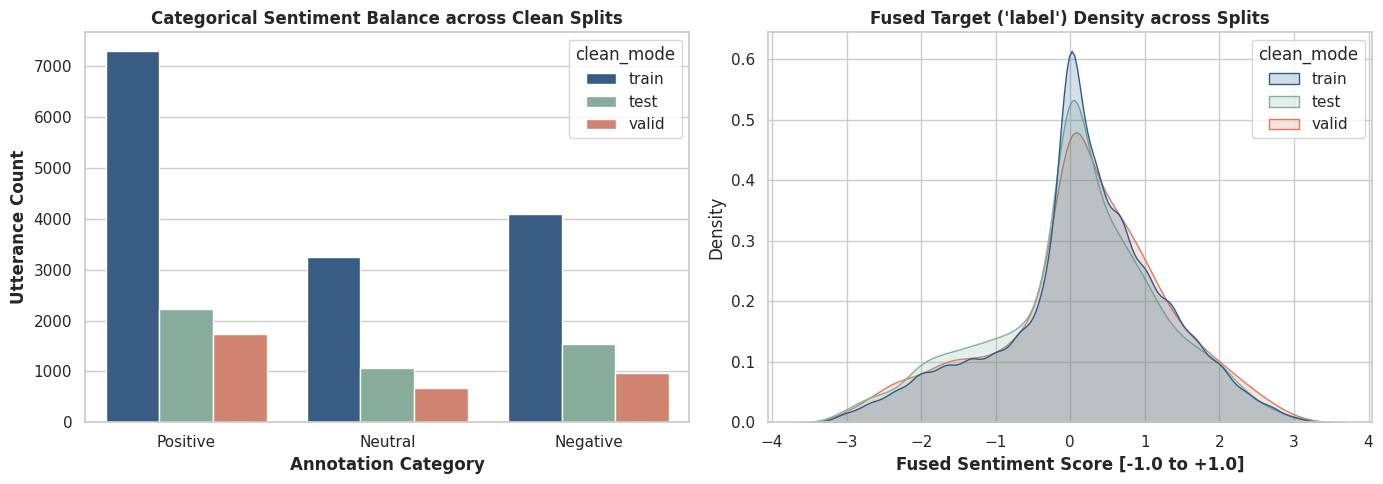

In [9]:
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('/content/drive/MyDrive/CMU-MOSEI/label.csv')

# GroupSplit at video_id level
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_outer.split(df, groups=df['video_id']))

df_train_val = df.iloc[train_val_idx]
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.1875, random_state=42) # ~15% total val
train_sub_idx, val_sub_idx = next(gss_inner.split(df_train_val, groups=df_train_val['video_id']))

# Map back using original index mapping
val_idx = train_val_idx[val_sub_idx]
train_idx = train_val_idx[train_sub_idx]

df['clean_mode'] = 'train'
df.loc[val_idx, 'clean_mode'] = 'valid'
df.loc[test_idx, 'clean_mode'] = 'test'

# Verification check
leak_check = df.groupby('video_id')['clean_mode'].nunique()
print(f"Parent videos spanning multiple splits: {(leak_check > 1).sum()}")
assert (leak_check > 1).sum() == 0, "Leakage still present!"
print("✅ FIXED: 0 Parent Video Leakage across splits!\n")
print(df['clean_mode'].value_counts())
sns.set_theme(style="whitegrid", font="sans-serif")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Discrete Label Counts by Split
palette_splits = {"train": "#2b5c8f", "valid": "#e07a5f", "test": "#81b29a"}
sns.countplot(data=df, x='annotation', hue='clean_mode', palette=palette_splits, ax=axes[0])
axes[0].set_title("Categorical Sentiment Balance across Clean Splits", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Annotation Category", fontweight='bold')
axes[0].set_ylabel("Utterance Count", fontweight='bold')

# Plot B: Continuous Label Density Overlay
sns.kdeplot(data=df, x='label', hue='clean_mode', palette=palette_splits, common_norm=False, fill=True, alpha=0.2, ax=axes[1])
axes[1].set_title("Fused Target ('label') Density across Splits", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Fused Sentiment Score [-1.0 to +1.0]", fontweight='bold')

plt.tight_layout()
plt.show()

,count,percent
sentiment,,
Positive,11264,49.28
Negative,6594,28.85
Neutral,4998,21.87


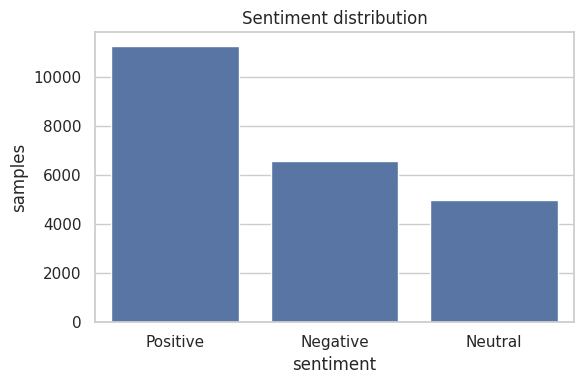

,count
split,
train,16326
test,4659
valid,1871


sentiment,Negative,Neutral,Positive
split,,,
test,1350,1025,2284
train,4738,3540,8048
valid,506,433,932


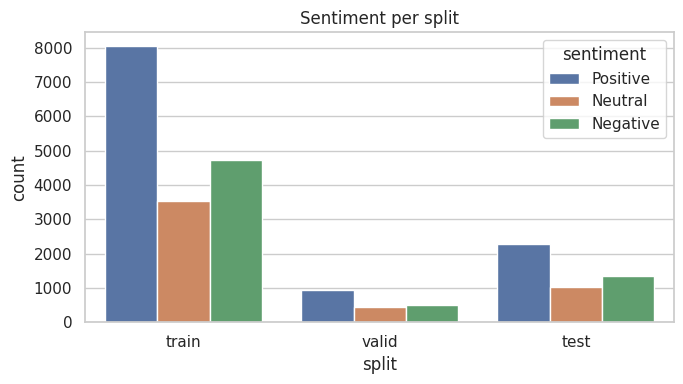

,count,mean,std,min,25%,50%,75%,max
label,22856.0,0.148976,1.114437,-3.0,-0.333333,0.0,1.0,3.0


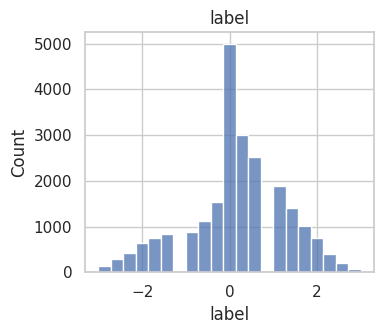

,text_word_len
count,22856.000000
mean,19.758225
std,13.387724
min,1.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,309.000000


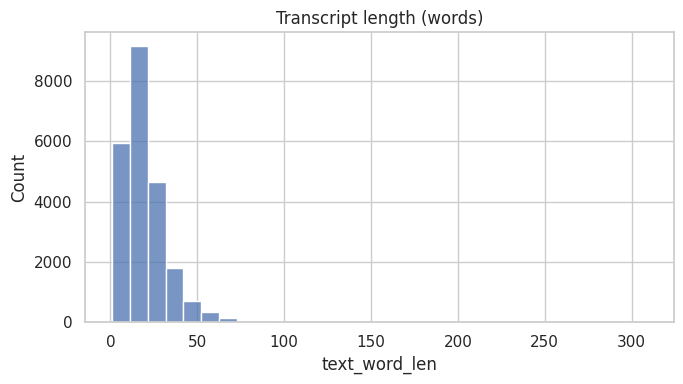

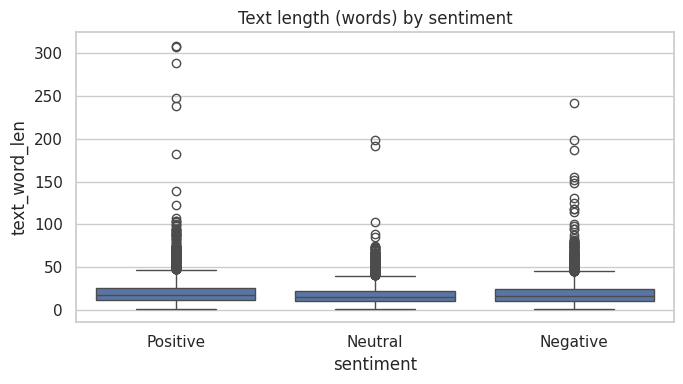

,modality,samples
0,Text,22856
1,Audio,22856
2,Video,22856


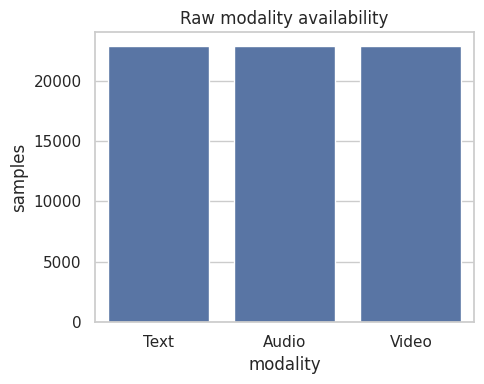

Complete 3-modality samples: 22856 / 22856


In [10]:
# --- sentiment class: the file's own column if present, otherwise derived from the main label ---
if "sentiment" not in labels_df.columns:
    labels_df["sentiment"] = np.where(labels_df[LABEL_COLUMN] < 0, "Negative",
                              np.where(labels_df[LABEL_COLUMN] > 0, "Positive", "Neutral"))
if "split" in labels_df.columns:
    labels_df["split"] = labels_df["split"].astype(str).str.lower().replace({"val": "valid", "validation": "valid", "dev": "valid"})

labels_df["text_char_len"] = labels_df.text.astype(str).str.len()
LANG = "en"
if LANG == "en":
    labels_df["text_word_len"] = labels_df.text.astype(str).str.split().str.len()    # English: words are meaningful
LEN_COL = "text_word_len" if LANG == "en" else "text_char_len"
LEN_NAME = "words" if LANG == "en" else "characters"

def savefig(name):
    plt.tight_layout(); plt.savefig(FIG_ROOT / name, dpi=160, bbox_inches="tight"); plt.show()

# 1) sentiment distribution
vc = labels_df.sentiment.value_counts()
display(pd.DataFrame({"count": vc, "percent": (vc / vc.sum() * 100).round(2)}))
fig, ax = plt.subplots(figsize=(6, 4)); sns.barplot(x=vc.index, y=vc.values, ax=ax)
ax.set_title("Sentiment distribution"); ax.set_ylabel("samples"); savefig("01_sentiment_distribution.png")

# 2) split distribution (+ sentiment per split)
if "split" in labels_df.columns:
    display(labels_df.split.value_counts().to_frame("count"))
    display(pd.crosstab(labels_df.split, labels_df.sentiment))
    fig, ax = plt.subplots(figsize=(7, 4)); sns.countplot(data=labels_df, x="split", hue="sentiment", ax=ax)
    ax.set_title("Sentiment per split"); savefig("02_sentiment_by_split.png")

# 3) numeric label distributions + correlation
display(labels_df[NUM_LABELS].describe().T)
fig, axes = plt.subplots(1, len(NUM_LABELS), figsize=(4 * len(NUM_LABELS), 3.5), squeeze=False)
for ax, c in zip(axes[0], NUM_LABELS):
    sns.histplot(labels_df[c], bins=21, ax=ax); ax.set_title(c)
savefig("03_label_distributions.png")
if len(NUM_LABELS) > 1:
    corr = labels_df[NUM_LABELS].corr(); display(corr.round(3))
    fig, ax = plt.subplots(figsize=(5, 4)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
    ax.set_title("Label correlation"); savefig("04_label_correlation.png")
    corr.to_csv(TABLE_ROOT / "label_correlation.csv")

# 4) text length
display(labels_df[LEN_COL].describe().to_frame())
fig, ax = plt.subplots(figsize=(7, 4)); sns.histplot(labels_df[LEN_COL], bins=30, ax=ax)
ax.set_title(f"Transcript length ({LEN_NAME})"); savefig("05_text_length.png")
fig, ax = plt.subplots(figsize=(7, 4)); sns.boxplot(data=labels_df, x="sentiment", y=LEN_COL, ax=ax)
ax.set_title(f"Text length ({LEN_NAME}) by sentiment"); savefig("06_text_length_by_sentiment.png")

# 5) modality availability (from raw files)
avail = pd.DataFrame({"modality": ["Text", "Audio", "Video"],
                      "samples": [labels_df.has_text.sum(), labels_df.has_audio.sum(), labels_df.has_video.sum()]})
display(avail)
fig, ax = plt.subplots(figsize=(5, 4)); sns.barplot(data=avail, x="modality", y="samples", ax=ax)
ax.set_title("Raw modality availability"); savefig("07_modality_availability.png")
labels_df["complete_3modal"] = labels_df[["has_text", "has_audio", "has_video"]].all(axis=1)
print("Complete 3-modality samples:", int(labels_df.complete_3modal.sum()), "/", len(labels_df))

labels_df.to_csv(TABLE_ROOT / "raw_eda_dataframe.csv", index=False)
vc.to_csv(TABLE_ROOT / "sentiment_distribution.csv"); avail.to_csv(TABLE_ROOT / "modality_availability.csv", index=False)
labels_df[NUM_LABELS].describe().T.to_csv(TABLE_ROOT / "label_statistics.csv")

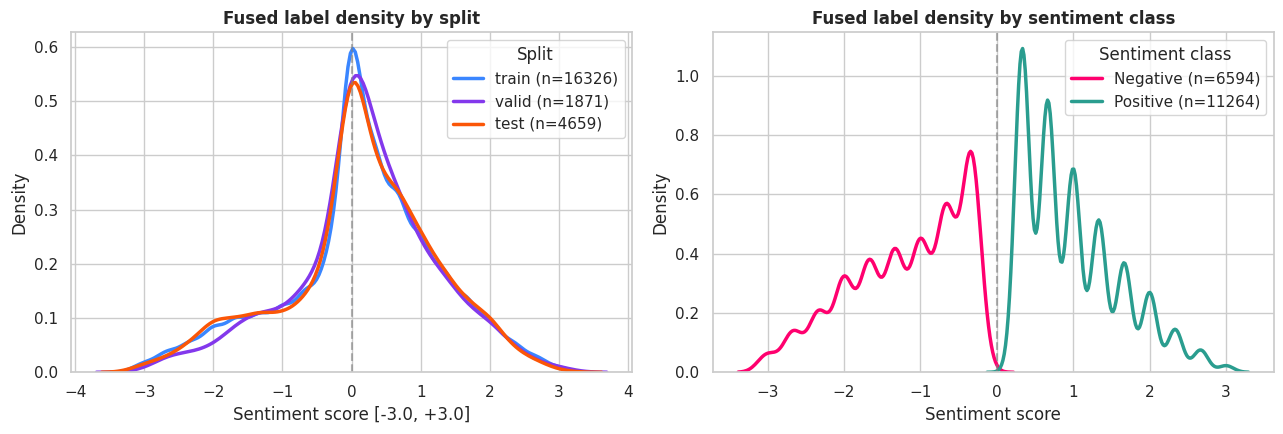

In [18]:
# A) Fused-label density by split and by sentiment class (works for any dataset)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if "split" in labels_df.columns:
    for s, color in zip(["train", "valid", "test"], ["#3A86FF", "#8338EC", "#FB5607"]):
        d = labels_df.loc[labels_df.split == s, LABEL_COLUMN].dropna()
        if len(d) > 1: sns.kdeplot(d, ax=axes[0], label=f"{s} (n={len(d)})", color=color, linewidth=2.5)
    axes[0].legend(title="Split", frameon=True)
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.6)
axes[0].set_title("Fused label density by split", fontweight="bold")
axes[0].set_xlabel(f"Sentiment score [{labels_df[LABEL_COLUMN].min():+.1f}, {labels_df[LABEL_COLUMN].max():+.1f}]")

for cls, color in zip(["Negative", "Neutral", "Positive"], ["#FF006E", "#8D99AE", "#2A9D8F"]):
    d = labels_df.loc[labels_df.sentiment == cls, LABEL_COLUMN].dropna()
    if len(d) > 1: sns.kdeplot(d, ax=axes[1], label=f"{cls} (n={len(d)})", color=color, linewidth=2.5)
axes[1].axvline(0, color="gray", linestyle="--", alpha=0.6)
axes[1].legend(title="Sentiment class", frameon=True)
axes[1].set_title("Fused label density by sentiment class", fontweight="bold")
axes[1].set_xlabel("Sentiment score")
savefig("09_label_density_split_and_class.png")

## 6. Feature extraction setup
Features are **cached to Drive** after each modality, so a Colab disconnect does not lose finished work. Set `FORCE_RECOMPUTE=True` to redo them.

In [12]:
assert RUN_FEATURES, "RUN_FEATURES=False -> stopped after EDA (set it True in the config cell to continue)."

import torch, torch.nn as nn
from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "(Runtime -> Change runtime type -> GPU makes BERT / ResNet much faster)")

ids = [k for k in labels_df.sample_id if k in video_map]      # samples that have a video (and hence audio)
print("Samples to process:", len(ids))
FAILS = {"text": [], "audio": [], "visual": []}

def cached(name, fn):
    p = CACHE_ROOT / f"{name}.pkl"
    if p.exists() and not FORCE_RECOMPUTE:
        print(f"[cache] loaded {p.name}")
        return pickle.load(open(p, "rb"))
    out = fn()
    pickle.dump(out, open(p, "wb"), protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[cache] saved  {p.name}")
    return out

Device: cpu (Runtime -> Change runtime type -> GPU makes BERT / ResNet much faster)
Samples to process: 22856


## 7. Audio extraction (ffmpeg, parallel, resumable)

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def _one(k):
    if k in audio_map:
        return k, audio_map[k], None
    out = WAV_DIR / f"{k}.wav"
    if out.exists() and out.stat().st_size > 1000:          # already converted -> skip
        return k, out, None
    tmp = WAV_DIR / f"{k}.tmp.wav"
    r = subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(video_map[k]),
                        "-vn", "-ac", "1", "-ar", "16000", str(tmp)],
                       capture_output=True, text=True)
    if r.returncode != 0 or not tmp.exists():
        return k, None, r.stderr[:200]
    tmp.rename(out)       # a half-written file (disconnect mid-write) is never mistaken for a finished one
    return k, out, None

def make_wavs(workers=8):
    out_map, errors = {}, []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_one, k) for k in ids]
        for f in tqdm(as_completed(futs), total=len(futs), desc="ffmpeg -> wav"):
            k, path, err = f.result()
            if path is not None: out_map[k] = path
            else: errors.append((k, err))
    print(f"wav ready: {len(out_map)} | ffmpeg failures: {len(errors)}")
    for k, e in errors[:3]: print("ffmpeg failed:", video_map[k], "|", e)
    return out_map

wav_map = make_wavs()

ffmpeg -> wav:   0%|          | 0/22856 [00:00<?, ?it/s]

wav ready: 22856 | ffmpeg failures: 0


## 8. TEXT — BERT (CLS embedding, 768-d)

In [14]:
def run_bert():
    from transformers import AutoTokenizer, AutoModel
    tok  = AutoTokenizer.from_pretrained(TEXT_MODEL)
    bert = AutoModel.from_pretrained(TEXT_MODEL).to(device).eval()
    feats = {}
    for i in tqdm(range(0, len(ids), 32), desc=f"BERT ({TEXT_MODEL})"):
        batch = ids[i:i + 32]
        try:
            enc = tok([text_map[k] for k in batch], return_tensors="pt", truncation=True,
                      max_length=MAX_TEXT_LEN, padding=True).to(device)
            with torch.no_grad():
                cls = bert(**enc).last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
            for k, v in zip(batch, cls): feats[k] = v
        except Exception as e:
            for k in batch: FAILS["text"].append((k, repr(e)))
    del bert
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return feats

text_feat = cached("text_bert", run_bert)
print("text features:", len(text_feat), "| dim:", next(iter(text_feat.values())).shape, "| failures:", len(FAILS["text"]))
print("first failures:", FAILS["text"][:3])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT (bert-base-uncased):   0%|          | 0/715 [00:00<?, ?it/s]

[cache] saved  text_bert.pkl
text features: 22856 | dim: (768,) | failures: 0
first failures: []


## 9. AUDIO — openSMILE eGeMAPSv02 functionals (88-d)

In [15]:
def run_opensmile():
    import opensmile
    smile = opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02,
                            feature_level=opensmile.FeatureLevel.Functionals)
    feats = {}
    for k in tqdm(ids, desc="openSMILE"):
        if k not in wav_map: continue
        try:
            feats[k] = smile.process_file(str(wav_map[k])).values[0].astype(np.float32)
        except Exception as e:
            FAILS["audio"].append((k, repr(e)))
    return feats

audio_feat = cached("audio_opensmile", run_opensmile)
print("audio features:", len(audio_feat), "| dim:", next(iter(audio_feat.values())).shape, "| failures:", len(FAILS["audio"]))
print("first failures:", FAILS["audio"][:3])

openSMILE:   0%|          | 0/22856 [00:00<?, ?it/s]

[cache] saved  audio_opensmile.pkl
audio features: 22856 | dim: (88,) | failures: 0
first failures: []


## 10. VISUAL — ResNet18 (avg-pool, 512-d, mean over sampled frames)

In [ ]:
def run_resnet():
    import cv2
    from PIL import Image
    import torchvision.models as tvm
    w = tvm.ResNet18_Weights.DEFAULT
    resnet = nn.Sequential(*list(tvm.resnet18(weights=w).children())[:-1]).to(device).eval()
    tf = w.transforms()

    def vec(path):
        cap = cv2.VideoCapture(str(path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release(); raise RuntimeError("video has 0 frames")
        frames = []
        for idx in np.linspace(0, total - 1, min(N_FRAMES, total), dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx)); ok, fr = cap.read()
            if ok: frames.append(tf(Image.fromarray(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))))   # PIL image (numpy would fail)
        cap.release()
        if not frames: raise RuntimeError("no frame could be decoded")
        with torch.no_grad():
            return resnet(torch.stack(frames).to(device)).flatten(1).mean(0).cpu().numpy().astype(np.float32)

    feats = {}
    for k in tqdm(ids, desc="ResNet18"):
        try:
            feats[k] = vec(video_map[k])
        except Exception as e:
            FAILS["visual"].append((k, repr(e)))
    return feats

visual_feat = cached("visual_resnet18", run_resnet)
print("visual features:", len(visual_feat), "| dim:", next(iter(visual_feat.values())).shape, "| failures:", len(FAILS["visual"]))
print("first failures:", FAILS["visual"][:3])

ResNet18:   0%|          | 0/22856 [00:00<?, ?it/s]

## 11. Final pickle
* `samples` – one dict per clip (missing modality = `None`, never fake zeros) with flags.
* `train` / `valid` / `test` – stacked arrays of **complete 3-modality samples** only (`text`, `audio`, `vision`, `labels`, `ids`, `raw_text`).

In [ ]:
lab = labels_df.set_index("sample_id")
rows = []
for k in labels_df.sample_id:
    r = lab.loc[k]
    rows.append({
        "id": k, "video_id": r["video_id"], "clip_id": int(float(r["clip_id"])),
        "text": text_feat.get(k), "acoustic": audio_feat.get(k), "visual": visual_feat.get(k),
        "label": float(r[LABEL_COLUMN]), "sentiment": r["sentiment"],
        "split": r["split"] if "split" in lab.columns else None, "raw_text": text_map[k],
        "has_text": k in text_feat, "has_acoustic": k in audio_feat, "has_visual": k in visual_feat,
    })
df = pd.DataFrame(rows)
df["complete"] = df[["has_text", "has_acoustic", "has_visual"]].all(axis=1)

def stack_split(d):
    d = d[d.complete]
    return {
        "text":   np.stack(d.text.values).astype(np.float32),        # (N, 768)
        "audio":  np.stack(d.acoustic.values).astype(np.float32),    # (N, 88)
        "vision": np.stack(d.visual.values).astype(np.float32),      # (N, 512)
        "labels": d.label.values.astype(np.float32),                 # (N,)  main regression label
        "ids":    d.id.tolist(), "raw_text": d.raw_text.tolist(),
        "sentiment": d.sentiment.tolist(),
    }

payload = {
    "dataset": DATASET_NAME,
    "feature_reference": {"text": f"{TEXT_MODEL} CLS (768)",
                          "acoustic": "openSMILE eGeMAPSv02 functionals (88)",
                          "visual": f"ResNet18 avgpool, mean of {N_FRAMES} frames (512)"},
    "label_definition": f"{LABEL_COLUMN} = main continuous sentiment label; 'sentiment' = class label from the file (or sign of the label)",
    "samples": rows,
}
if "split" in df.columns and df.split.notna().any():
    for s in ["train", "valid", "test"]:
        part = df[df.split == s]
        if len(part) and part.complete.any():
            payload[s] = stack_split(part)
else:
    payload["all"] = stack_split(df)

pkl = ARTIFACT_ROOT / "cmu_mosei_raw_features.pkl"
with open(pkl, "wb") as f: pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:", pkl, f"({pkl.stat().st_size/1024**2:.1f} MB)")
if (~df.complete).any():
    print(f"NOTE: {(~df.complete).sum()} samples lack a modality and are excluded from the train/valid/test arrays "
          "(they remain in 'samples' with None).")

## 12. Sanity check — reload the pickle, shapes, dtypes, statistics, zero-vector check

In [ ]:
with open(pkl, "rb") as f: chk = pickle.load(f)
SPL = [s for s in ["train", "valid", "test", "all"] if s in chk]

print("Top-level keys:", list(chk.keys()))
rows_chk = []
for s in SPL:
    d = chk[s]
    rows_chk.append({"split": s, "N": len(d["labels"]),
                     "text": d["text"].shape, "audio": d["audio"].shape, "vision": d["vision"].shape,
                     "dtype": str(d["text"].dtype),
                     "labels": f"{d['labels'].min():.1f}..{d['labels'].max():.1f}"})
summary = pd.DataFrame(rows_chk); display(summary)

print("\nPer-modality statistics over all complete samples:")
stat_rows = []
for m in ["text", "audio", "vision"]:
    arr = np.concatenate([chk[s][m] for s in SPL])
    stat_rows.append({"modality": m, "shape": arr.shape, "mean": arr.mean(), "std": arr.std(),
                      "min": arr.min(), "max": arr.max(),
                      "nan": int(np.isnan(arr).sum()),
                      "all_zero_rows": int((np.abs(arr).sum(1) == 0).sum())})
stats = pd.DataFrame(stat_rows); display(stats)
assert stats.all_zero_rows.sum() == 0 and stats.nan.sum() == 0, "zero/NaN features found - inspect FAILS"

print("\n--- final dataframe head ---")
display(df[["id", "raw_text", "label", "sentiment", "split", "has_text", "has_acoustic", "has_visual", "complete"]].head())
print("Complete 3-modality:", int(df.complete.sum()), "/", len(df))

# L2 norm of the final features, with a readable y-axis (about 5 ticks, e.g. 0, 2000, 4000 ...)
from matplotlib.ticker import MultipleLocator
fig, ax = plt.subplots(figsize=(6, 4))
norms = pd.DataFrame({m: np.linalg.norm(np.concatenate([chk[s][m] for s in SPL]), axis=1) for m in ["text", "audio", "vision"]})
sns.boxplot(data=norms, ax=ax)
raw_step = norms.values.max() / 5
mag = 10 ** np.floor(np.log10(raw_step))
step = next(m_ * mag for m_ in (1, 2, 5, 10) if m_ * mag >= raw_step)      # 1, 2, 5 x 10^k  (e.g. 2000)
ax.set_ylim(0, np.ceil(norms.values.max() / step) * step)
ax.yaxis.set_major_locator(MultipleLocator(step))
ax.set_title("L2 norm of final features"); ax.set_ylabel("L2 norm")
savefig("08_feature_norms.png")
print("Median L2 norm per modality:", norms.median().round(2).to_dict(),
      "-> audio features are on a much larger scale: z-score them (train split only) before training.")

summary.to_csv(TABLE_ROOT / "final_feature_summary.csv", index=False)
stats.to_csv(TABLE_ROOT / "final_feature_stats.csv", index=False)
json.dump({"failures": {k: len(v) for k, v in FAILS.items()}, "pickle": str(pkl)},
          open(OUT_ROOT / "run_summary.json", "w"), indent=2)
print("\nDONE. Pickle:", pkl)